<h1>Objekterkennung mit YOLO</h1>

In diesem Tutorial geht es um die Objekterkennung mit einem vortrainierten Netz. Dafür wird
* eine Kamera (eingebaut oder extern z.B. über USB) benötigt, dazu
* die Bibliothek YOLO von Ultralytics, das ist die eigentliche Objekterkennung und
* OpenCV für Python, vorwiegend für die Bedienung der Kamera

YOLO (You Only Look Once) ist ein neuronales Netz zur Objekterkennung in Bildern und Videos. Es erkennt gleichzeitig:
* was ein Objekt ist (Klasse, z. B. Person, Auto, Pflanze)
* wo es ist und welche Dimension das Objekt im Bild hat (Bounding Box)
* wie sicher die Erkennung ist (Confidence)
* Alles passiert in einem einzigen Durchlauf und damit sehr schnell, daher ist es ideal für Echtzeit - Anwendungen wie Drohnen, Roboter oder die Auswertung von Kameras.

OpenCV ist eine freie Programmbibliothek mit Algorithmen für die Bildverarbeitung und Computer Vision. Sie ist für die Programmiersprachen C, C++, Python und Java geschrieben und steht als freie Software unter den Bedingungen der Apache 2 License.

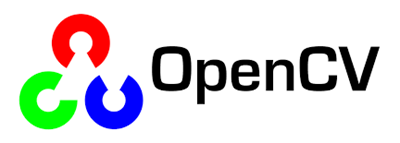

<h2>Vorbereitung</h2>

Als erstes müssen die Bibliotheken installiert werden, sofern sie noch nicht verfügbar sind:


In [ ]:
pip install opencv-python

In [ ]:
pip install ultralytics

<h2>Test der Installation</h2>

Das folgende Programm kann zum Test der Installation verwendet werden:

In [ ]:
from ultralytics import YOLO
import cv2

# Load a YOLO11n PyTorch model
model = YOLO("yolo11n.pt")
print(model.model_name)

print("OpenCV-Version:", cv2.__version__)

<h2>Test der Kamera</h2>

Das folgende Programm kann zum Test der Kamera verwendet werden. 

ACHTUNG: Die Methode VideoCapture() erwartet einen Index für die Kamera, die eingebaute Kamera hat normalerweise den Index 0, externe Kameras (USB) üblicherweise den Index 1. WICHTIG: Beim Test aus Jupyter heraus kann die Anwendung nicht einfach per Tastendruck beendet werden. Dazu bitte im Menü "Kernel" -> "Restart Kernel and Clear Outputs of All Cells ..." verwenden.

In [ ]:
import cv2
from ultralytics import YOLO

# Open the video streamq
cam = cv2.VideoCapture(0)

# Loop through the video frames
while cam.isOpened():
    # Read a frame from the video
    success, frame = cam.read()

    if success: 
         
        # Display the frame
        cv2.imshow("TEST", frame)

        # Break the loop if SPACE is pressed
        if cv2.waitKey(1) == ord(" "):
            break
    else:
        # Break the loop if t he end of the video is reached
        break

# Release the video capture object and close the display window
cam.release()
cv2.destroyAllWindows  

<h2>YOLO Standard Test</h2>

Das Programm lädt ein Bild von der URL 

https://ultralytics.com/images/bus.jpg" 

und verwendet ein vortrainiertes Netz "YOLO11" für die Klassifizierung von Objekten.

In [ ]:
from ultralytics import YOLO

# Load a YOLO11n PyTorch model
model = YOLO("yolo11n.pt")

# Run inference
results = model("https://ultralytics.com/images/bus.jpg")


# Visualize the results
for result in results:
    result.show()

<h2>Objekterkennung in Videos</h2>

Als erste Übung soll eine Objekterkennung in einem Video - Stream implementiert werden.

Aufgabe:
* Das unten folgende Programm soll erweitert werden
* Es wird ein Yolo11 - Modell erzeugt
* Der von der Kamera gelieferte Frame wird durch das Modell analysiert
* Die Results können mit der Methode plot() in den Frame hineingeschrieben werden
* Der veränderte Frame wird angezeigt 

In [ ]:
import cv2
from ultralytics import YOLO

# Load the YOLO model
model = YOLO("yolo11n.pt")

# Open the video streamq
cam = cv2.VideoCapture(0)

# Loop through the video frames
while cam.isOpened():
    # Read a frame from the video
    success, frame = cam.read()

    if success:
        # Run YOLO inference on the frame
        results = model(frame)

        # Visualize the results on the frame
        annotated_frame = results[0].plot()

        # Display the annotated frame
        cv2.imshow("YOLO", annotated_frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) == ord("q"):
            break
    else:
        # Break the loop if the end of the video is reached
        break

# Release the video capture object and close the display window
cam.release()
cv2.destroyAllWindows